In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
# Importamos métricas para evaluar el modelo de machine learning.
from sklearn.metrics import mean_absolute_error, r2_score
# Definimos una semilla aleatoria para que los resultados sean reproducibles.
np.random.seed (123)

##1.Parámetros del modelo

Antes de simular, debemos definir los supuestos actuariales.
Estos supuestos representan una cartera hipotética de seguros. Pueden modificarse para construir otros escenarios.
* Media Logarítmica de Severidad = controla "qué tan grandes son las pérdidas".
* Sigma_logaritmica de severidad= controla "qué tan impredecibles son las pérdidas".

In [ ]:
#Definimos en número de escenarios que vamos a simular.

n_simulaciones=10000

#Definimos el promedio anual esperado de sinisestros por cartera. (real)
lambda_frecuencia=80

#Definimos la media logaritmica de la severidad de los sinisesteos
media_log_severidad=8.5

#Definimos la desviacion estandar logaritmica de la severidad.
sigma_log_severidad=0.90

#Definimos el nivel de confianza para calcular VaR y TVaR.
nivel_confianza=0.95

#Imprimir reporte de los parametros del modelo
print("numero de simulaciones", n_simulaciones)
print("Lambda frecuencia:",lambda_frecuencia)
print("media_log_severidad:", media_log_severidad)
print("sigma_log_severidad:",sigma_log_severidad)
print("nivel_confianza:", nivel_confianza)


numero de simulaciones 10000
Lambda frecuencia: 80
media_log_severidad: 8.5
sigma_log_severidad: 0.9
nivel_confianza: 0.95


##Simulación de frecuencia de siniestros

La frecuencia indica cuántos siniestros ocurren en un periodo determinado.

En este ejemplo usamos una distribución Poisson porque es una distribución clásica para modelar conteos de eventos.

In [ ]:
# Simulamos el número de siniestros para cada escenario anual.
#La distribución Poisson se usa cuando queremos modelar cantidad de accidentes;


frecuencia=np. random.poisson(lam=lambda_frecuencia, size=n_simulaciones)
frecuencia_promedio=np. mean (frecuencia)
frecuencia_desviacion=np.std (frecuencia)
#Busca el escenario con MAYOR/MENOR cantidad de siniestros.
print("Frecuencia mínima simulada:", np.min(frecuencia))
print("Frecuencia máxima simulada:", np.max(frecuencia))
print("Frecuencia promedio simulada:", round (frecuencia_promedio, 2))
print("Desviación estándar simulada:", round (frecuencia_desviacion, 2))


Frecuencia mínima simulada: 49
Frecuencia máxima simulada: 118
Frecuencia promedio simulada: 80.0
Desviación estándar simulada: 9.02


##Grafico No.1 - Distribucion Simulada de la frecuencia de Siniestros

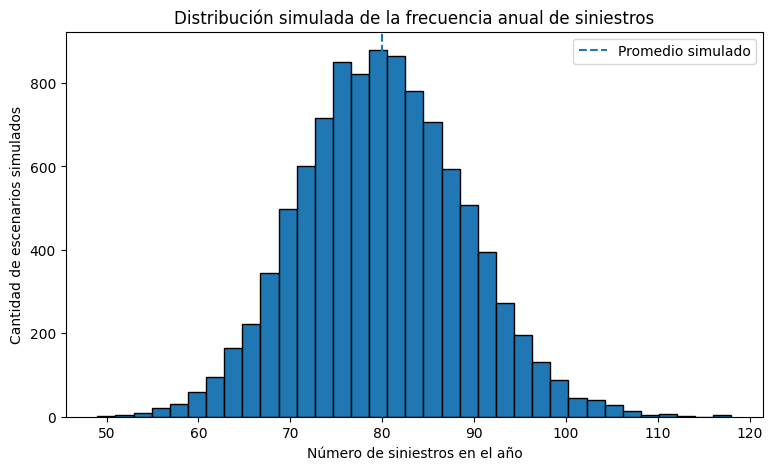

In [ ]:
# Creamos una figura para el gráfico de frecuencia.
plt.figure(figsize= (9, 5))
plt.hist(frecuencia, bins=35, edgecolor="black")
plt.title("Distribución simulada de la frecuencia anual de siniestros")
plt.xlabel( "Número de siniestros en el año")
plt.ylabel("Cantidad de escenarios simulados")
plt.axvline(frecuencia_promedio, linestyle="--", label="Promedio simulado")
plt.legend()
plt.show()

Desde una perspectiva actuarial, esto permite visualizar la variabilidad natural del número de reclamaciones.

Aunque el promedio sea 80, no todos los años tendrán exactamente 80 siniestros. Algunos años tendrán menos y otros tendrán más.

##Simulación de severidades individuales

La severidad representa el monto económico de cada siniestro.

En seguros, las severidades suelen ser asimétricas: muchos siniestros pequeños y pocos siniestros muy grandes.

Por eso usaremos una distribución Lognormal.

In [ ]:
# Calculamos el total de siniestros individuales que necesitamos simular.
total_siniestros=np.sum(frecuencia)

#Simulamos severidades individuales usando una distribución lognormal.
severidades=np.random.lognormal(
    mean=media_log_severidad,
    sigma=sigma_log_severidad,
    size=total_siniestros
)

# Calculamos la severidad promedio simulada.
severidad_promedio=np.mean(severidades)

# Calculamos la mediana de las severidades simuladas.
severidad_mediana=np.median(severidades)

# Calculamos el percentil 95 de las severidades simuladas.
severidad_p95=np.percentile(severidades, 95)

# Mostramos resultados descriptivos de la severidad.
print("Total de siniestros individuales simulados:", total_siniestros)
print("Severidad promedio:", round(severidad_promedio, 2))
print("Severidad mediana:", round(severidad_mediana, 2))
print("Percentil 95 de severidad:", round(severidad_p95, 2))

Total de siniestros individuales simulados: 799984
Severidad promedio: 7375.22
Severidad mediana: 4911.08
Percentil 95 de severidad: 21675.51


##Gráfico 2. Distribución de severidades individuales

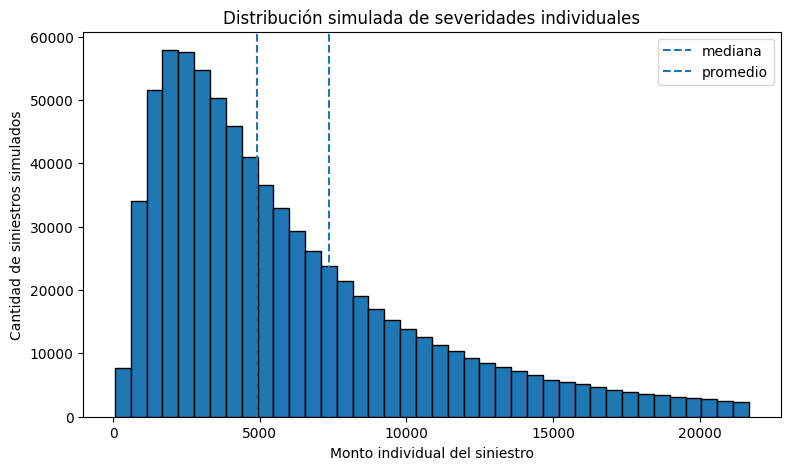

In [ ]:
# Creamos una figura para el histograma de severidades.
plt.figure(figsize=(9, 5))
plt.hist(severidades[severidades <= np.percentile(severidades, 95)], bins=40, edgecolor="black")
plt.title("Distribución simulada de severidades individuales")
plt.xlabel("Monto individual del siniestro")
plt.ylabel("Cantidad de siniestros simulados")
plt.axvline(severidad_mediana, linestyle="--", label="mediana")
plt.axvline(severidad_promedio, linestyle="--", label="promedio")
plt.legend()
plt.show()

##Análisis del Gráfico 2

El gráfico muestra una distribución sesgada hacia la derecha. Esto significa que la mayoría de los siniestros son de monto moderado o bajo, pero existen algunos siniestros mucho más grandes.

Desde el punto de vista actuarial, esta característica es fundamental: una pequeña cantidad de siniestros grandes puede tener un efecto fuerte sobre la pérdida total.

##Construcción de la pérdida agregada anual

Ahora sumaremos las severidades correspondientes a cada escenario.

Cada escenario representa un posible año de experiencia siniestral para la cartera.

In [ ]:
# Creamos una lista vacía para guardar la pérdida agregada de cada escenario.
perdidas_agregadas = []

# Creamos una posición inicial para recorrer el vector de severidades.
posicion=0
# Recorremos cada frecuencia anual simulada.
for n in frecuencia:
  # Seleccionamos las severidades que corresponden al escenario actual.
  severidades_escenario = severidades[posicion: posicion + n]

  # Sumamos las severidades para obtener la pérdida agregada anual.
  perdida_total = np.sum(severidades_escenario)

  #Guardamos la pérdida total del escenario.
  perdidas_agregadas.append(perdida_total)


  # Actualizamos la posicion para el siguiente escenario.
  posicion = posicion + n


#Convertimos la lista de pérdida promedio anual simulada.
perdidas_agregadas=np.array(perdidas_agregadas)

# Calculamos la pérdida promedio anual simulada.
perdida_promedio = np. mean(perdidas_agregadas)

# Calculamos la mediana de la pérdida agregada.
perdida_mediana = np.median(perdidas_agregadas)

# Mostramos resultados principales.
print("Pérdida agregada promedio:", round(perdida_promedio, 2))
print("Mediana de pérdida agregada:", round(perdida_mediana, 2))
print("Pérdida agregada mínima:", round(np.min(perdidas_agregadas), 2))
print("Pérdida agregada máxima:", round(np.max(perdidas_agregadas), 2))


Pérdida agregada promedio: 590005.85
Mediana de pérdida agregada: 583768.71
Pérdida agregada mínima: 257639.96
Pérdida agregada máxima: 1119169.8


#Gráfico 3. Distribución de pérdida agregada anual

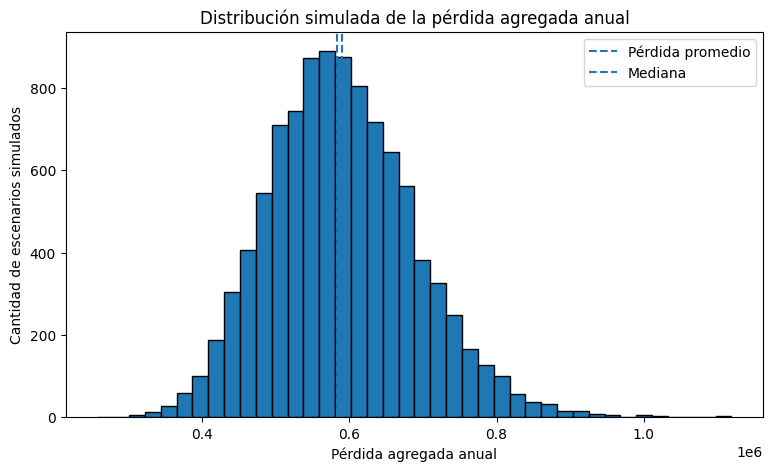

In [ ]:
# Creamos una figura para el histograma de pérdida agregada.
plt.figure(figsize=(9, 5))
plt.hist(perdidas_agregadas, bins=40, edgecolor="black")
plt.title("Distribución simulada de la pérdida agregada anual")
plt.xlabel("Pérdida agregada anual")
plt.ylabel("Cantidad de escenarios simulados")
plt.axvline(perdida_promedio, linestyle="--", label="Pérdida promedio")
plt.axvline(perdida_mediana, linestyle="--", label="Mediana")
plt. legend()
plt.show()

La pérdida agregada es el corazón del análisis actuarial de cartera. Con ella se pueden estimar primas, reservas, capital económico y riesgo de insolvencia.

Este gráfico muestra que una cartera no debe gestionarse solo con el valor esperado. También deben evaluarse los escenarios adversos, porque la estabilidad financiera depende de sobrevivir a los años malos, no solo de celebrar los años buenos.

##Cálculo de prima pura

La prima pura es la prima necesaria para cubrir la pérdida esperada, sin considerar gastos, utilidad, comisiones ni margen de seguridad

In [ ]:
# Calculamos la prima pura como la pérdida agregada promedio.
prima_pura = perdida_promedio

# Mostramos la prima pura estimada.
print("Prima pura estimada:", round(prima_pura, 2))

Prima pura estimada: 590005.85


##Interpretación actuarial de la prima pura

La prima pura representa el costo esperado del riesgo. Si la aseguradora cobrara exactamente esta cantidad por toda la cartera, en promedio cubriría las pérdidas esperadas.

Sin embargo, cobrar solo la prima pura puede ser insuficiente en la práctica porque no incluye gastos administrativos, comisiones, impuestos, utilidad ni margen por riesgo.

#Conclusión
La simulación Monte Carlo permite estimar la prima pura de forma flexible. Su ventaja es que no exige fórmulas cerradas complejas; basta con simular muchos escenarios realistas de la cartera.

##**Medidas de riesgo: VaR y TVaR**

En actuaria, no basta con saber la pérdida promedio. También interesa saber qué puede ocurrir en escenarios extremos.

Usaremos dos medidas:

**Var al 95%:** pérdida que solo se supera en el 5% de los escenarios.

**TVaR al 95%:** promedio de las pérdidas que superan el VaR al 95%.

El VaR señala un umbral. El TVaR mira qué tan grave es la cola después de ese umbral

In [ ]:
# Calculamos el VaR al nivel de confianza definido.
var_95 = np.percentile(perdidas_agregadas, nivel_confianza * 100)

# Seleccionamos las pérdidas que superan o igualan el VaR.
perdidas_extremas = perdidas_agregadas[perdidas_agregadas >= var_95]

# Calculamos el TVaR como el promedio de las pérdidas extremas.
tvar_95 = np.mean(perdidas_extremas)

# Calculamos el margen de riesgo entre TVaR y prima pura.
margen_riesgo = tvar_95 - prima_pura

# Mostramos resultados de riesgo.
print("VaR 95%;", round(var_95, 2))
print("TVaR 95%:", round(tvar_95, 2))
print("Margen de riesgo TVaR - Prima pura:", round(margen_riesgo, 2))

VaR 95%; 762254.75
TVaR 95%: 818066.91
Margen de riesgo TVaR - Prima pura: 228061.06


##Gráfico 4. VaR y TVar sobre la Distribución de pérdida agregada

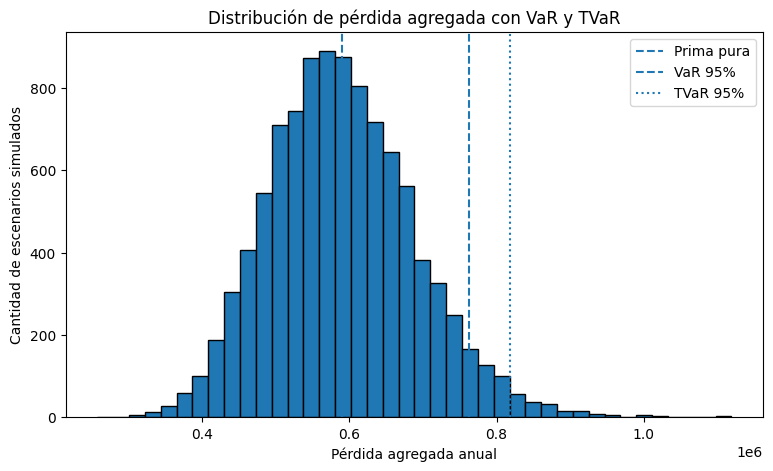

In [ ]:
plt.figure(figsize=(9, 5))
plt.hist(perdidas_agregadas, bins=40, edgecolor="black")
plt.axvline(prima_pura, linestyle="--", label="Prima pura")
plt.axvline(var_95, linestyle="--", label="VaR 95%")
plt.axvline(tvar_95, linestyle=":", label="TVaR 95%")
plt.title("Distribución de pérdida agregada con VaR y TVaR")
plt.xlabel("Pérdida agregada anual")
plt.ylabel("Cantidad de escenarios simulados")
plt.legend()
plt.show()

El VaR responde: "¿hasta cuánto podría perder en un escenario adverso razonable?". EI VaR responde algo más duro: si las cosas salen mal, ¿qué tan mal podrían salir en promedio?”

##Probabilidad de insuficiencia de prima

Supongamos que la aseguradora cobra una prima total igual a la prima pura más un margen de seguridad del 15%.

Analizaremos la probabilidad de que la pérdida anual supere esa prima cobrada.

In [ ]:
# Definimos un margen de seguridad del 15%.
margen_seguridad = 0.15
# Calculamos la prima total cobrada con margen de seguridad.
prima_con_margen = prima_pura * (1 + margen_seguridad)

# Calculamos cuántos escenarios superan la prima con margen.
escenarios_insuficientes = perdidas_agregadas > prima_con_margen

# Calculamos la probabilidad de insuficiencia de prima.
probabilidad_insuficiencia = np.mean(escenarios_insuficientes)

# Mostramos resultados.
print("Prima con margen del 15%:", round(prima_con_margen, 2))
print("Probabilidad de insuficiencia:", round(probabilidad_insuficiencia, 4))

Prima con margen del 15%: 678506.73
Probabilidad de insuficiencia: 0.1758


##Gráfico 5.

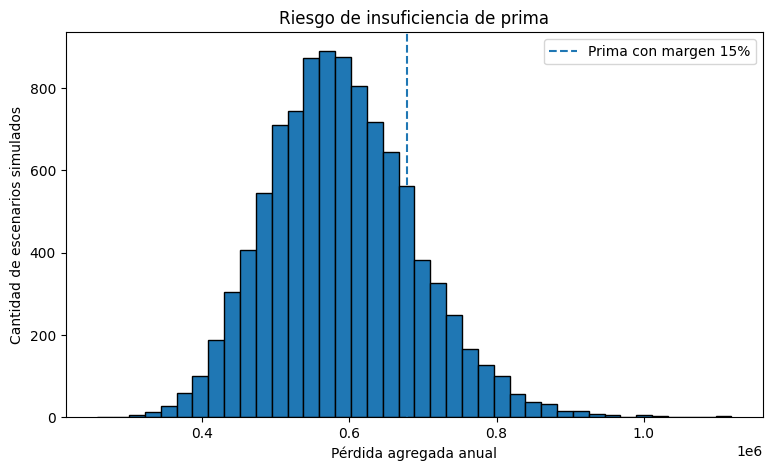

In [ ]:
plt. figure(figsize=(9, 5))
plt.hist(perdidas_agregadas, bins=40, edgecolor="black")
plt.axvline(prima_con_margen, linestyle="--", label="Prima con margen 15%")
plt.title("Riesgo de insuficiencia de prima")
plt.xlabel("Pérdida agregada anual")
plt.ylabel("Cantidad de escenarios simulados")
plt.legend()
plt.show()

línea vertical representa la prima total cobrada con un margen del 15%.
Los escenarios ubicados a la derecha de esa línea son años en los que la pérdida agregada supera la prima cobrada. En esos casos, la cartera tendria resultado técnico negativo antes de considerar otros ingresos o mecanismos de protección

Curva de Pérdida Acumulads
La función de distribución

## Curva de pérdida acumulada

La función de distribución acumulada empírica permite observar qué porcentaje de escenarios queda por debajo de determinado nivel de pérdida.

In [ ]:
# Ordenamos las pérdidas agregadas de menor a mayor.
perdidas_ordenadas = np.sort(perdidas_agregadas)

# Construimos probabilidades acumuladas para cada pérdida ordenada.
probabilidades_acumuladas = np.arange(1, n_simulaciones + 1) / n_simulaciones

# Mostramos los primeros cinco valores ordenados como ejemplo.
print("Primeras cinco pérdidas ordenadas:", np.round(perdidas_ordenadas[:5], 2))

Primeras cinco pérdidas ordenadas: [257639.96 284300.92 302162.89 306971.3  319238.02]


##Gráfico 6. Función de distribución acumulada empírica

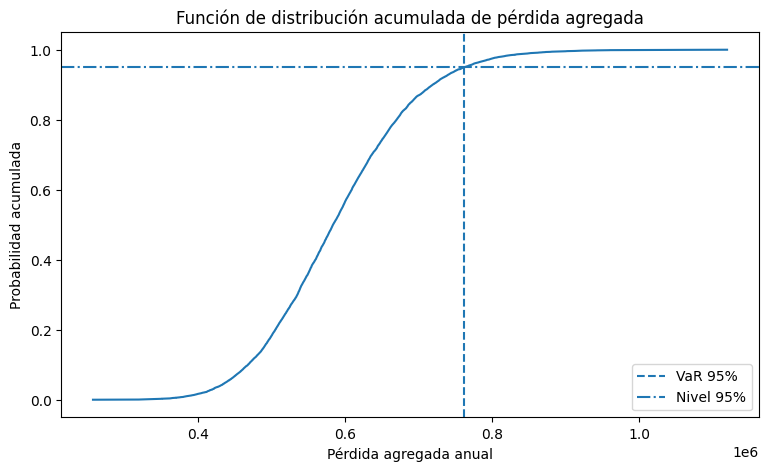

In [ ]:
# Creamos una figura para la curva acumulada.
plt.figure(figsize=(9, 5))

# Graficamos la pérdida ordenada contra la probabilidad acumulada.
plt.plot(perdidas_ordenadas, probabilidades_acumuladas)

# Agregamos una línea vertical para el VaR.
plt.axvline(var_95, linestyle="--", label="VaR 95%")

# Agregamos una línea horizontal en el nivel de confianza.
plt.axhline(nivel_confianza, linestyle="-.", label="Nivel 95%")

# Agregamos el título del gráfico.
plt.title("Función de distribución acumulada de pérdida agregada")

# Agregamos la etiqueta del eje X.
plt.xlabel("Pérdida agregada anual")

# Agregamos la etiqueta del eje Y.
plt.ylabel("Probabilidad acumulada")

# Mostramos la leyenda.
plt.legend()

# Mostramos el gráfico.
plt.show()

La curva acumulada indica la proporción de escenarios con pérdidas menores o iguales a cada nivel del eje horizontal.

El cruce entre el nivel de confianza del 95% y la curva permite identificar visualmente el VaR. Esto ayuda a explicar que el VaR no es un promedio, sino un percentil de la distribución simulada.

##Análisis de escenarios: frecuencia alta y severidad alta

Ahora clasificaremos escenarios en categorías simples para interpretar mejor la cartera.

Esta parte es útil para enseñar cómo la simulación permite pasar de números sueltos a decisiones de gestión.

In [ ]:
# Calculamos el percentil 75 de la frecuencia.
frecuencia_p75 = np.percentile(frecuencia, 75)

# Calculamos el percentil 75 de la pérdida agregada.
perdida_p75 = np.percentile(perdidas_agregadas, 75)

# Identificamos escenarios con frecuencia alta.
frecuencia_alta = frecuencia >= frecuencia_p75

# Identificamos escenarios con pérdida agregada alta.
perdida_alta = perdidas_agregadas >= perdida_p75

# Calculamos la proporción de escenarios con frecuencia y pérdida altas.
proporcion_doble_alta = np.mean(frecuencia_alta & perdida_alta)

# Mostramos el resultado.
print("Percentil 75 de frecuencia:", frecuencia_p75)
print("Percentil 75 de pérdida:", round(perdida_p75, 2))
print("Proporción con frecuencia alta y pérdida alta:", round(proporcion_doble_alta, 4))

Percentil 75 de frecuencia: 86.0
Percentil 75 de pérdida: 652927.85
Proporción con frecuencia alta y pérdida alta: 0.1511


##*Gráfico 7. Relación entre frecuencia y pérdida agregada*

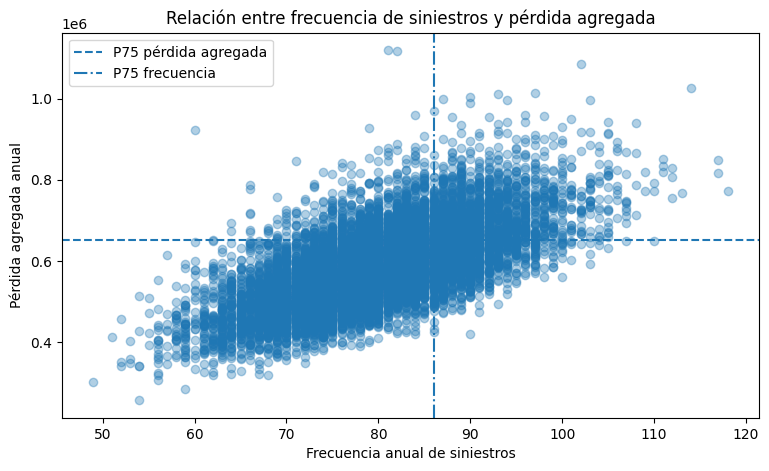

In [ ]:
# Creamos una figura para el gráfico de dispersión.
plt.figure(figsize=(9, 5))

# Construimos el gráfico de dispersión entre frecuencia y pérdida agregada.
plt.scatter(frecuencia, perdidas_agregadas, alpha=0.35)

# Agregamos línea horizontal del percentil 75 de pérdida.
plt.axhline(perdida_p75, linestyle="--", label="P75 pérdida agregada")

# Agregamos línea vertical del percentil 75 de frecuencia.
plt.axvline(frecuencia_p75, linestyle="-.", label="P75 frecuencia")

# Agregamos el título del gráfico.
plt.title("Relación entre frecuencia de siniestros y pérdida agregada")

# Agregamos la etiqueta del eje X.
plt.xlabel("Frecuencia anual de siniestros")

# Agregamos la etiqueta del eje Y.
plt.ylabel("Pérdida agregada anual")

# Mostramos la leyenda.
plt.legend()

# Mostramos el gráfico.
plt.show()

El gráfico de dispersión muestra la relación entre el número de siniestros y la pérdida agregada anual.

En general, una mayor frecuencia tiende a aumentar la pérdida total. Sin embargo, el gráfico también muestra que no basta con contar siniestros: algunos escenarios con frecuencia moderada pueden presentar pérdidas altas si ocurren siniestros severos.

Esto refleja una idea actuarial importante: el riesgo total depende tanto de frecuencia como de severidad.

##Aplicación básica de machine learning

La simulación Monte Carlo puede generar datos sintéticos para entrenar modelos predictivos.

A continuación construiremos un modelo de regresión lineal muy sencillo para predecir la pérdida agregada usando la frecuencia como variable explicativa.

Este ejemplo no busca reemplazar el juicio actuarial. Busca mostrar cómo simulación y machine learning pueden trabajar juntos.

In [ ]:
# Creamos un DataFrame con los resultados simulados.
datos = pd.DataFrame({
    "frecuencia": frecuencia,
    "perdida_agregada": perdidas_agregadas
})

# Definimos la variable explicativa X.
X = datos[["frecuencia"]]

# Definimos la variable objetivo y.
y = datos["perdida_agregada"]

# Separamos los datos en entrenamiento y prueba.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=2026
)

# Creamos el modelo de regresión lineal.
modelo = LinearRegression()

# Entrenamos el modelo con los datos de entrenamiento.
modelo.fit(X_train, y_train)

# Generamos predicciones sobre los datos de prueba.
predicciones = modelo.predict(X_test)

# Calculamos el error absoluto medio.
mae = mean_absolute_error(y_test, predicciones)

# Calculamos el coeficiente de determinación R2.
r2 = r2_score(y_test, predicciones)

# Mostramos resultados del modelo.
print("Intercepto del modelo:", round(modelo.intercept_, 2))
print("Coeficiente de frecuencia:", round(modelo.coef_[0], 2))
print("Error absoluto medio:", round(mae, 2))
print("R2 del modelo:", round(r2, 4))

Intercepto del modelo: 1646.78
Coeficiente de frecuencia: 7355.31
Error absoluto medio: 57874.47
R2 del modelo: 0.4321


##Gráfico 8. Predicción de pérdida agregada usando machine learning

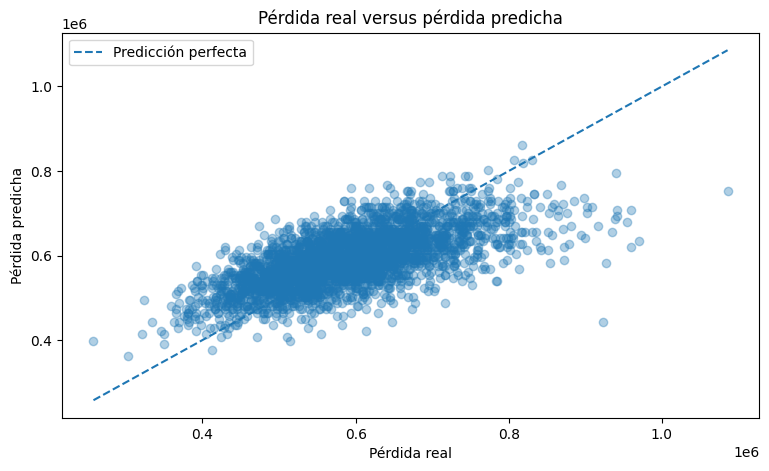

In [ ]:
# Creamos una figura para comparar valores reales y predichos.
plt.figure(figsize=(9, 5))

# Graficamos los valores reales contra las predicciones.
plt.scatter(y_test, predicciones, alpha=0.35)

# Calculamos el menor valor para la línea de referencia.
minimo = min(y_test.min(), predicciones.min())

# Calculamos el mayor valor para la línea de referencia.
maximo = max(y_test.max(), predicciones.max())

# Graficamos una línea de referencia perfecta.
plt.plot([minimo, maximo], [minimo, maximo], linestyle="--", label="Predicción perfecta")

# Agregamos el título del gráfico.
plt.title("Pérdida real versus pérdida predicha")

# Agregamos la etiqueta del eje X.
plt.xlabel("Pérdida real")

# Agregamos la etiqueta del eje Y.
plt.ylabel("Pérdida predicha")

# Mostramos la leyenda.
plt.legend()

# Mostramos el gráfico.
plt.show()

El gráfico compara las pérdidas reales simuladas con las pérdidas predichas por el modelo de regresión lineal.

Si el modelo fuera perfecto, todos los puntos caerían sobre la línea diagonal. Sin embargo, se observa dispersión alrededor de esa línea, lo cual indica error de predicción.

La razón principal es que la frecuencia no captura toda la variabilidad de la pérdida agregada. La severidad de los siniestros también influye de manera importante.

##*Tabla resumen de resultados actuariales*

In [ ]:
# Creamos una tabla con los principales indicadores actuariales.
resumen = pd.DataFrame({
    "Indicador": [
        "Frecuencia promedio",
        "Severidad promedio",
        "Prima pura",
        "VaR 95%",
        "TVaR 95%",
        "Prima con margen 15%",
        "Probabilidad de insuficiencia",
        "MAE modelo ML",
        "R2 modelo ML"
    ],
    "Valor": [
        frecuencia_promedio,
        severidad_promedio,
        prima_pura,
        var_95,
        tvar_95,
        prima_con_margen,
        probabilidad_insuficiencia,
        mae,
        r2
    ]
})

# Redondeamos los valores para facilitar la lectura.
resumen["Valor"] = resumen["Valor"].round(4)

# Mostramos la tabla resumen.
resumen

,Indicador,Valor
0,Frecuencia promedio,79.9984
1,Severidad promedio,7375.2206
2,Prima pura,590005.8485
3,VaR 95%,762254.7526
4,TVaR 95%,818066.9127
5,Prima con margen 15%,678506.7257
6,Probabilidad de insuficiencia,0.1758
7,MAE modelo ML,57874.4726
8,R2 modelo ML,0.4321


La simulación Monte Carlo realizada en el notebook permitió estimar el comportamiento de las pérdidas agregadas anuales mediante la generación de miles de escenarios aleatorios. Como resultado, se obtuvo una distribución probabilística de pérdidas con un promedio cercano a los 600,000 dólares, identificando además medidas clave de riesgo como la prima pura esperada, el VaR al 95% y el TVaR al 95%, los cuales permiten evaluar la suficiencia financiera y el nivel de exposición ante eventos extremos. El histograma evidencia una distribución aproximadamente normal con ligera asimetría positiva, indicando que aunque la mayoría de las pérdidas se concentran alrededor del valor promedio, existen escenarios menos frecuentes con pérdidas considerablemente mayores